In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('music_streams.csv')
df.head(3)

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans


## Histogram

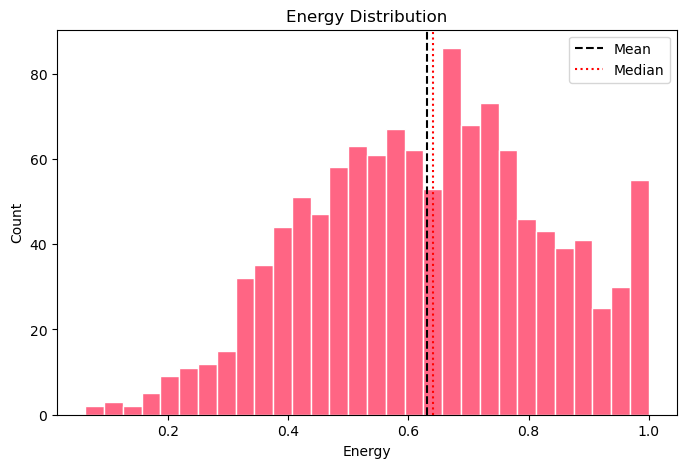

In [ ]:
mean = df['energy'].mean()
median = df['energy'].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['energy'], bins=30, color='#FF0000', edgecolor='white')
ax.axvline(mean, color='black', linestyle='--', linewidth=1.5, label='Mean')
ax.axvline(median, color='red',   linestyle=':',  linewidth=1.5, label='Median')
ax.set_xlabel('Energy')
ax.set_ylabel('Count')
ax.set_title('Energy Distribution')
ax.legend()

plt.show()

## Box Plot

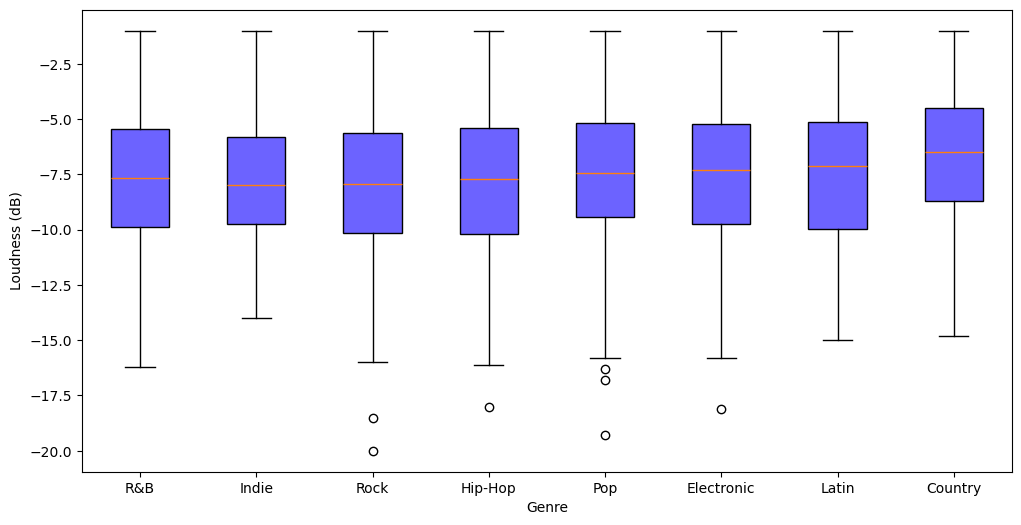

In [4]:
genre_order = ['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin', 'Country']
data = [df.loc[df['genre'] == g, 'loudness_db'].dropna().values for g in genre_order]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, tick_labels=genre_order, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('#6C63FF')

ax.set_xlabel('Genre')
ax.set_ylabel('Loudness (dB)')

plt.show()

## Scatter Plot

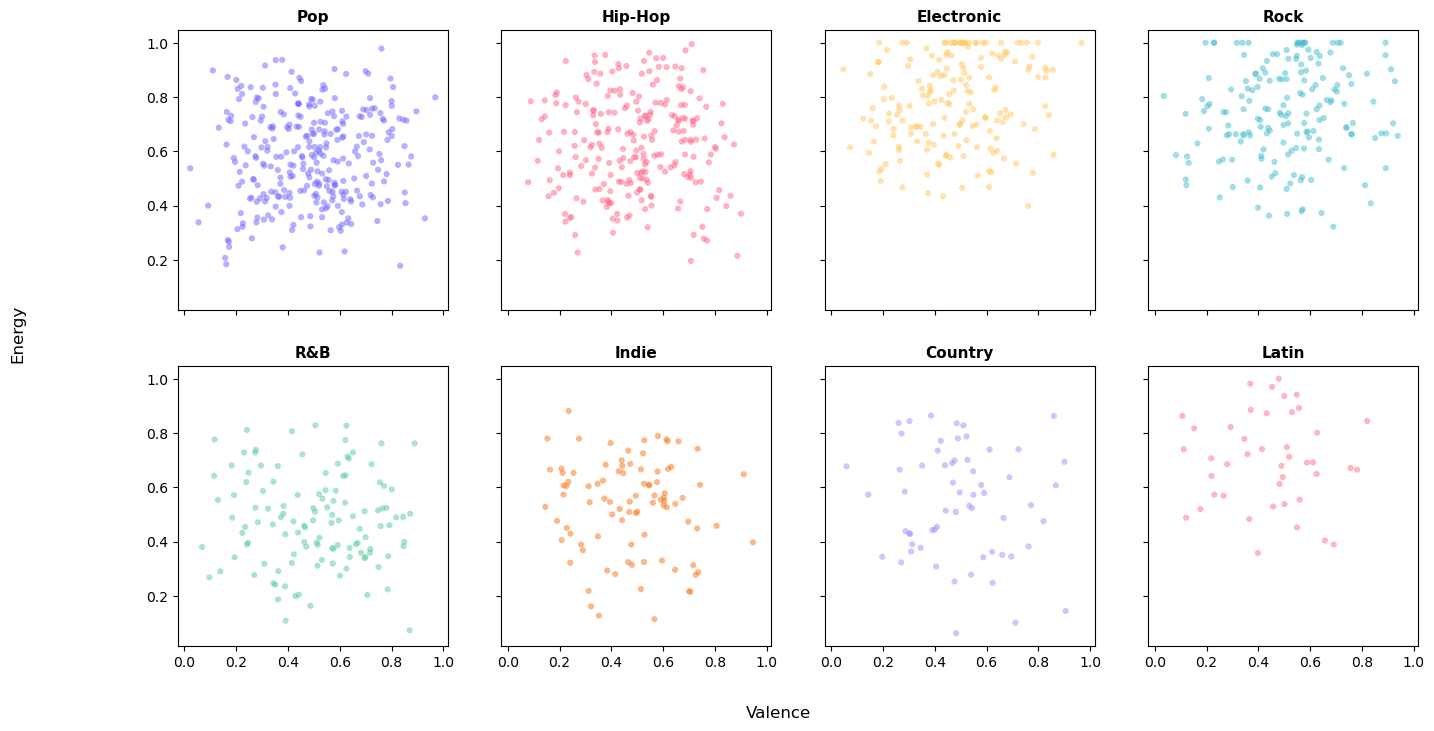

In [ ]:
genres = ['Pop', 'Hip-Hop', 'Electronic', 'Rock', 'R&B', 'Indie', 'Country', 'Latin']
colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00CC00', '#0000FF', '#4B0082', '#8B00FF', '#AAAAAA']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

for ax, genre, color in zip(axes.flat, genres, colors):
    subset = df[df['genre'] == genre]
    ax.scatter(subset['valence'], subset['energy'], color=color, alpha=0.5, s=20, edgecolors='none')
    ax.set_title(genre, fontsize=11, fontweight='bold')

fig.text(0.5, 0.02, 'Valence', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'Energy', va='center', rotation='vertical', fontsize=12)

plt.show()

## Line Chart

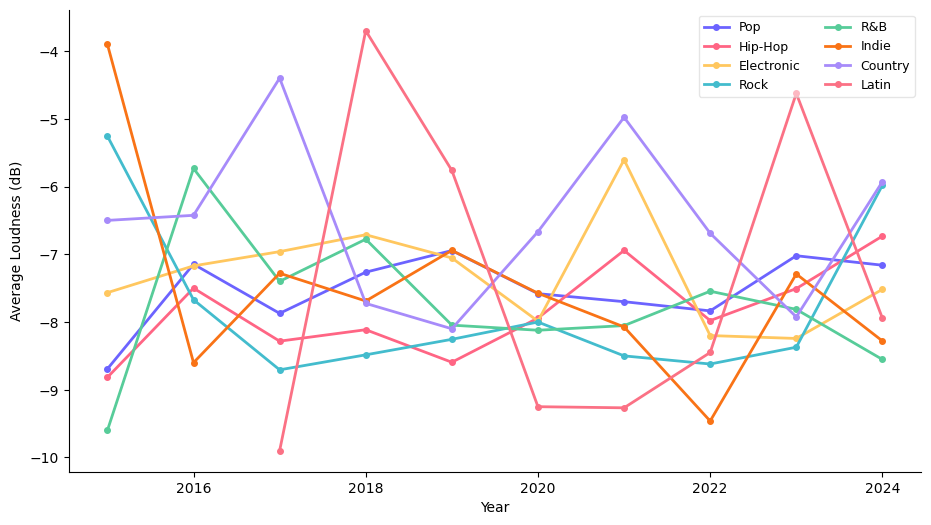

In [ ]:
yearly = df.groupby(['year', 'genre'])['loudness_db'].mean().unstack()

genres = ['Pop', 'Hip-Hop', 'Electronic', 'Rock', 'R&B', 'Indie', 'Country', 'Latin']
colors = ['#FF0000', '#FF7F00', '#FFFF00', '#00CC00', '#0000FF', '#4B0082', '#8B00FF', '#AAAAAA']

fig, ax = plt.subplots(figsize=(11, 6))

for genre, color in zip(genres, colors):
    ax.plot(yearly.index, yearly[genre], marker='o', linewidth=2, markersize=4, color=color, label=genre)

ax.set_xlabel('Year')
ax.set_ylabel('Average Loudness (dB)')
ax.legend(fontsize=9, ncol=2, framealpha=0.5, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.show()